# Suggested exercises

1. Repeat the lecture without StandardScaler and compare all results.
2. For Logistic Regression, choose the threshold that maximizes recall instead of F1.
3. On make_moons, try a denser grid of values and watch the boundary overfit.
4. Add class_weight="balanced" and test what changes on imbalanced synthetic data.
5. Compare LinearSVC and SVC(kernel="linear") on runtime and quality.


In [1]:
import warnings

from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.pylabtools import figsize
from openai.cli import display

from sklearn.datasets import (
    load_breast_cancer,
    load_wine,
    make_classification,
    make_moons,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC, SVC



In [2]:
# from lecture

warnings.filterwarnings("ignore", category=ConvergenceWarning)
np.random.seed(42)

ink = "#2f2a34"
paper = "#f6f1e7"
panel = "#efe4d6"
grid = "#ccbda8"

sns.set_theme(
    context="talk",
    style="ticks",
    palette=["#ff6b6b", "#1982c4", "#ffd166", "#2a9d8f", "#6a4c93"],
    rc={
        "figure.facecolor": paper,
        "axes.facecolor": panel,
        "savefig.facecolor": paper,
        "axes.edgecolor": ink,
        "axes.labelcolor": ink,
        "text.color": ink,
        "xtick.color": ink,
        "ytick.color": ink,
        "grid.color": grid,
        "grid.linestyle": ":",
        "grid.alpha": 0.55,
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titlelocation": "left",
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
        "legend.frameon": True,
        "legend.facecolor": "#fbf7f0",
        "legend.edgecolor": grid,
    },
)

surface_cmap = sns.blend_palette(
    ["#1f2041", "#4b3f72", "#417b5a", "#f4d35e", "#ee964b"], as_cmap=True
)
warm_cmap = sns.blend_palette(["#fff1d0", "#f4a261", "#e76f51"], as_cmap=True)
cool_cmap = sns.blend_palette(["#e0fbfc", "#4ea8de", "#293241"], as_cmap=True)
class_colors = ["#ff6b6b", "#1982c4", "#6a4c93", "#2a9d8f"]


def metric_frame(y_true, y_pred, y_score=None):
    rows = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        rows["roc_auc"] = roc_auc_score(y_true, y_score)
    return pd.DataFrame(
        {"metric": list(rows.keys()), "value": list(rows.values())}
    )


def make_grid(X, n=300, padding=1.0):
    x0_min, x0_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    x1_min, x1_max = X[:, 1].min() - padding, X[:, 1].max() + padding
    xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, n),
        np.linspace(x1_min, x1_max, n),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    return xx, yy, grid


def final_estimator(model):
    return model.named_steps["model"] if isinstance(model, Pipeline) else model


def scaler_step(model):
    if isinstance(model, Pipeline):
        return model.named_steps.get("scaler")
    return None


def score_on_grid(model, grid):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(grid)[:, 1]
    scores = model.decision_function(grid)
    min_score, max_score = scores.min(), scores.max()
    return (scores - min_score) / (max_score - min_score)


def plot_surface(ax, model, X, y, title, show_support=False, levels=28):
    xx, yy, grid = make_grid(X)
    z = score_on_grid(model, grid).reshape(xx.shape)

    ax.contourf(xx, yy, z, levels=levels, cmap=surface_cmap, alpha=0.94)
    ax.contour(xx, yy, z, levels=[0.5], colors="#fffaf1", linewidths=2.2)
    sns.scatterplot(
        x=X[:, 0],
        y=X[:, 1],
        hue=y,
        palette=class_colors[: len(np.unique(y))],
        s=60,
        edgecolor="#2b1d26",
        linewidth=0.4,
        legend=False,
        ax=ax,
    )

    if show_support and hasattr(final_estimator(model), "support_vectors_"):
        sv = final_estimator(model).support_vectors_
        scaler = scaler_step(model)
        if scaler is not None:
            sv = scaler.inverse_transform(sv)
        ax.scatter(
            sv[:, 0],
            sv[:, 1],
            s=220,
            facecolors="none",
            edgecolors="#fffaf1",
            linewidths=1.8,
        )

    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")


def plot_margin_surface(ax, model, X, y, title, show_support=True):
    xx, yy, grid = make_grid(X)
    scores = model.decision_function(grid).reshape(xx.shape)

    ax.contourf(xx, yy, scores, levels=28, cmap=surface_cmap, alpha=0.92)
    ax.contour(
        xx,
        yy,
        scores,
        levels=[-1, 0, 1],
        colors=["#f4d35e", "#fffaf1", "#4ecdc4"],
        linestyles=["--", "-", "--"],
        linewidths=[1.6, 2.3, 1.6],
    )
    sns.scatterplot(
        x=X[:, 0],
        y=X[:, 1],
        hue=y,
        palette=class_colors[: len(np.unique(y))],
        s=60,
        edgecolor="#2b1d26",
        linewidth=0.4,
        legend=False,
        ax=ax,
    )

    if show_support and hasattr(final_estimator(model), "support_vectors_"):
        sv = final_estimator(model).support_vectors_
        scaler = scaler_step(model)
        if scaler is not None:
            sv = scaler.inverse_transform(sv)
        ax.scatter(
            sv[:, 0],
            sv[:, 1],
            s=220,
            facecolors="none",
            edgecolors="#fffaf1",
            linewidths=1.8,
        )

    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")


def annotate_bars(ax, offset=None, fmt="{:.3f}"):
    ymin, ymax = ax.get_ylim()
    delta = (ymax - ymin) * 0.02 if offset is None else offset
    for patch in ax.patches:
        value = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            value + delta,
            fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=10,
        )


print("Theme loaded. Notebook ready.")

Theme loaded. Notebook ready.


# Repeating the lecture without StandardScaler and compare all results.

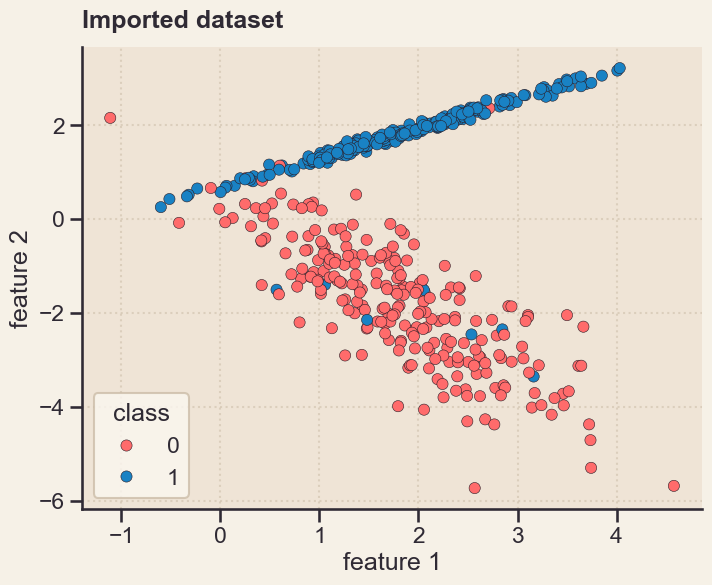

In [3]:
# df = load_breast_cancer()
# X = df.data[:,:2]
# y = df.target

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.8,
    flip_y=0.04,
    random_state=42,
)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x=X[:, 0],
    y=X[:, 1],
    hue=y,
    palette=class_colors[:2],
    s=65,
    edgecolor="#2b1d26",
    linewidth=0.4,
    ax=ax,
)
ax.set_title("Imported dataset")
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
ax.legend(title="class")
plt.show()

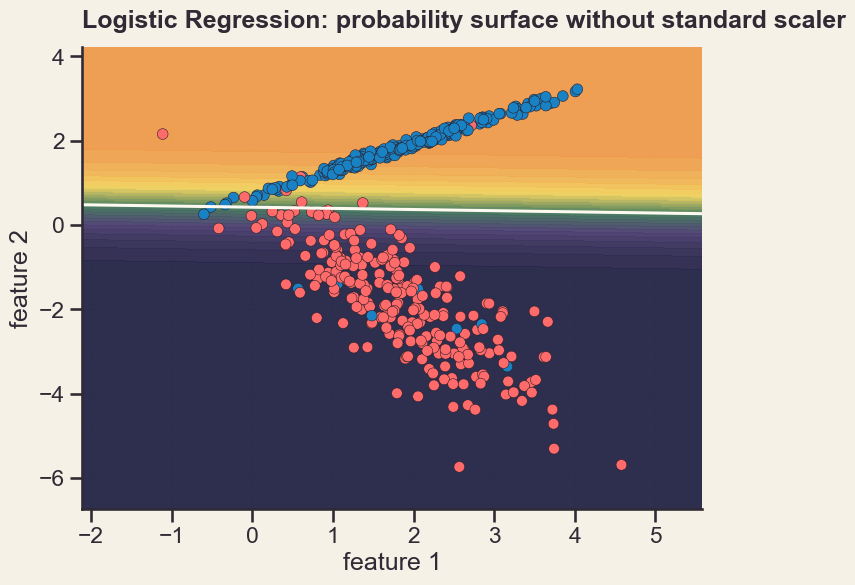

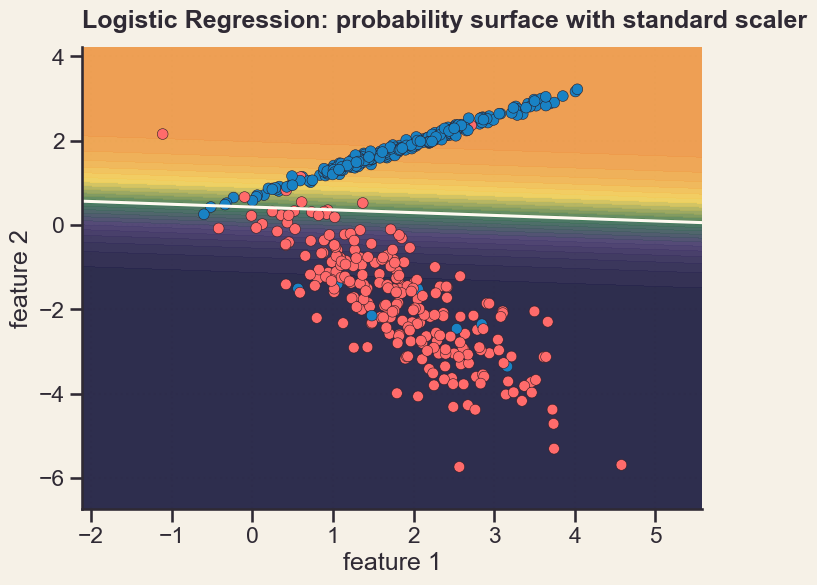

model,No Scaler,With Scaler
metric,,
accuracy,0.952,0.952
f1,0.953,0.953
precision,0.968,0.968
recall,0.938,0.938
roc_auc,0.955,0.955


In [4]:
logreg_no_scaler = LogisticRegression(C=1.0, max_iter=2000)
logreg_with = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(C=1.0, max_iter=2000)),
])
logreg_with.fit(X_train, y_train)
logreg_no_scaler.fit(X_train, y_train)

pred_logreg_no_scaler = logreg_no_scaler.predict(X_test)
prob_logreg_no_scaler = logreg_no_scaler.predict_proba(X_test)[:,1]

pred_logreg_with = logreg_with.predict(X_test)
prob_logreg_with = logreg_with.predict_proba(X_test)[:,1]

metrics_no_scaler = metric_frame(y_test, pred_logreg_no_scaler, prob_logreg_no_scaler)
metrics_no_scaler["model"] = "No Scaler"
metrics_logreg_with = metric_frame(y_test, pred_logreg_with, prob_logreg_with)
metrics_logreg_with["model"] = "With Scaler"

fig, ax = plt.subplots(figsize=(8, 6))
plot_surface(ax, logreg_no_scaler, X, y, "Logistic Regression: probability surface without standard scaler")

fig, ax = plt.subplots(figsize=(8,6))
plot_surface(ax, logreg_with, X, y, "Logistic Regression: probability surface with standard scaler")
plt.show()

compare_metric = pd.concat([metrics_no_scaler, metrics_logreg_with], ignore_index=True)

compare_metric.pivot(index='metric', columns='model', values='value').round(3)


Since the generated objects are naturally of similar scale and centered, applying StandardScaler has little effect on the LogisticRegression metric or its decision boundaries. Both models perform almost identically.

# For Logistic Regression, choose the threshold that maximizes recall instead of F1.

In [5]:
threshold_rows = []

for threshold in np.arange(0.0, 1.0, 0.05):
    pred_t = (prob_logreg_with >= threshold).astype(int)
    threshold_rows.append({
            "threshold": threshold,
            "recall": recall_score(y_test, pred_t, zero_division=0),
    })
threshold_frame = pd.DataFrame(threshold_rows)
threshold_plot = threshold_frame.melt( id_vars="threshold", var_name="metric", value_name="value")
threshold_frame.sort_values("recall", ascending=False).head(8).round(3)


,threshold,recall
0,0.00,1.000
1,0.05,0.938
2,0.10,0.938
3,0.15,0.938
4,0.20,0.938
5,0.25,0.938
6,0.30,0.938
7,0.35,0.938


The best value of for maximizing recall is threshold is 0.0

# On make_moons, try a denser grid of values and watch the boundary overfit.

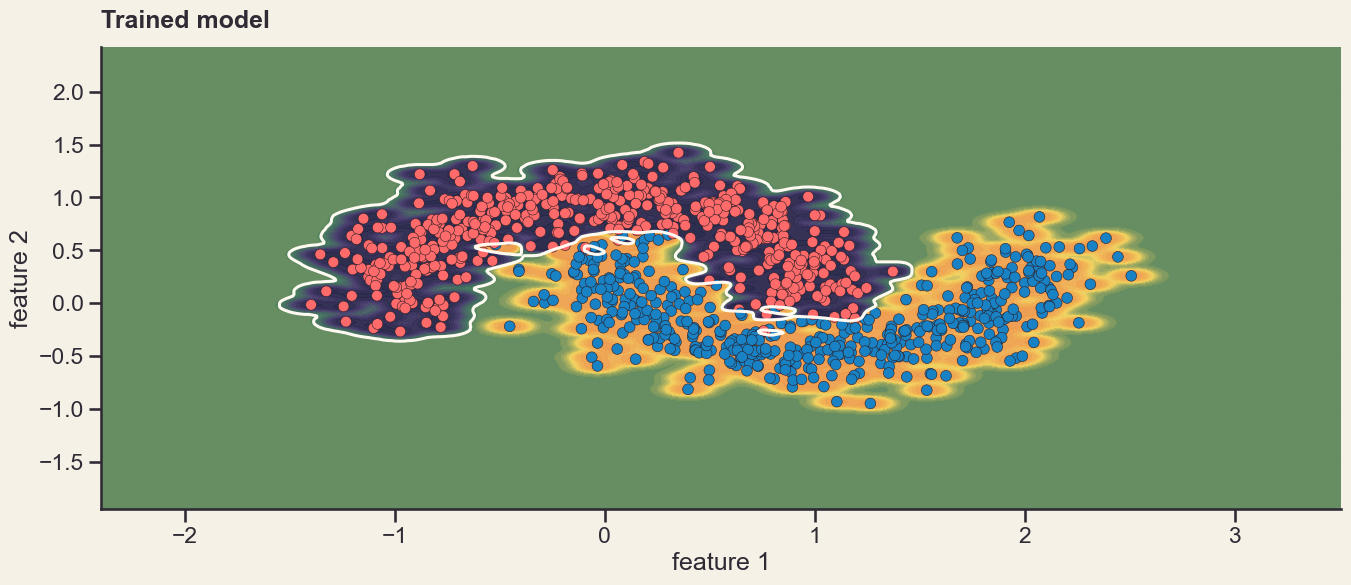

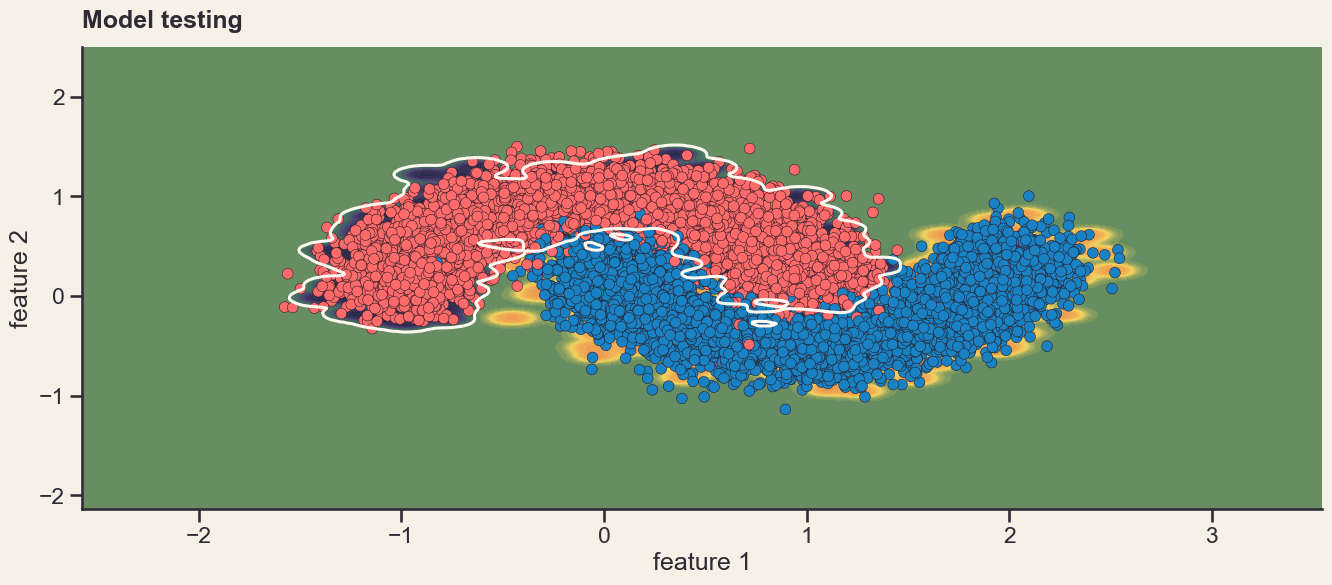

Test dataset

      metric     value
0   accuracy  0.966300
1  precision  0.959409
2     recall  0.973800
3         f1  0.966551
4    roc_auc  0.976330


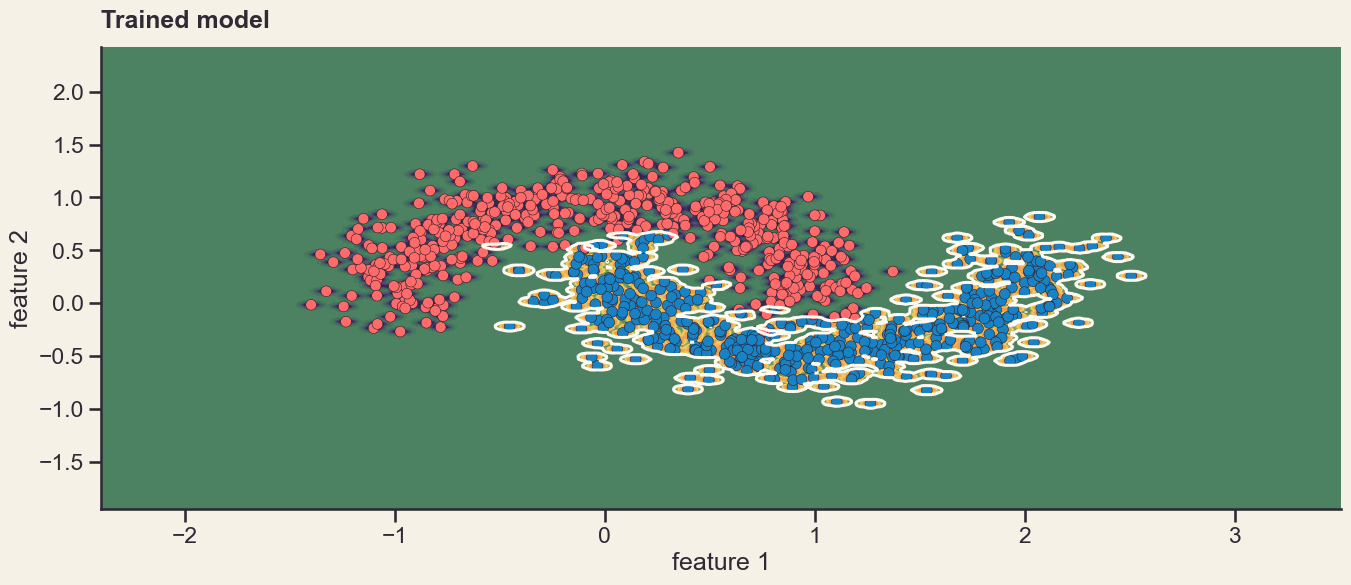

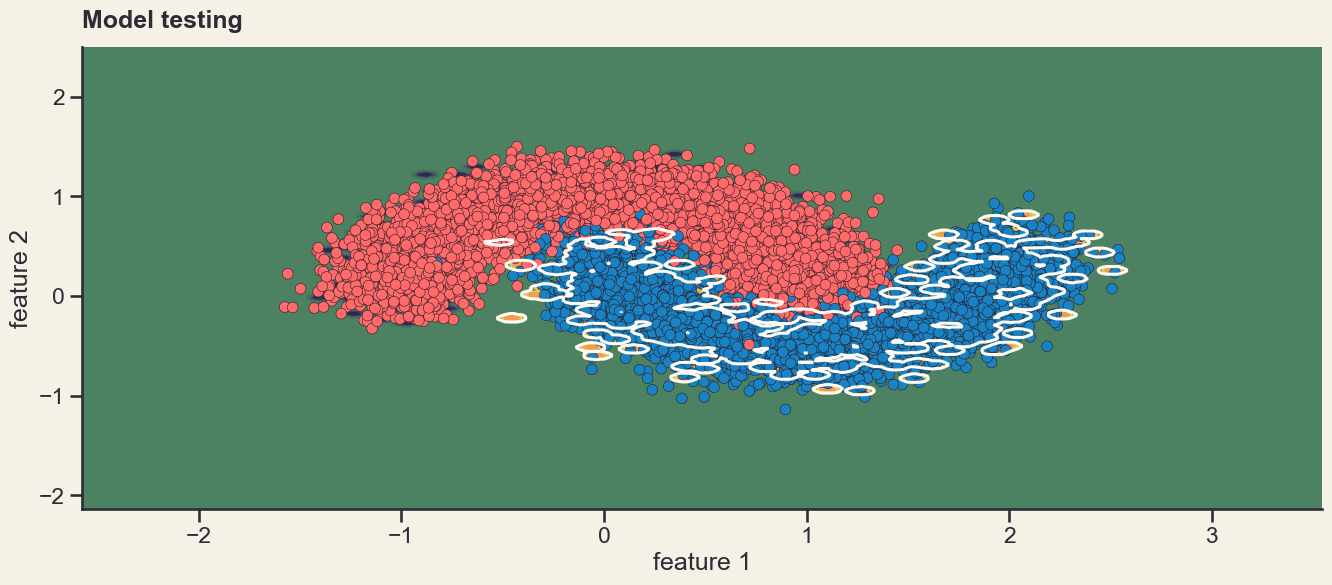

Test dataset

      metric     value
0   accuracy  0.879100
1  precision  0.980969
2     recall  0.773200
3         f1  0.864780
4    roc_auc  0.978446


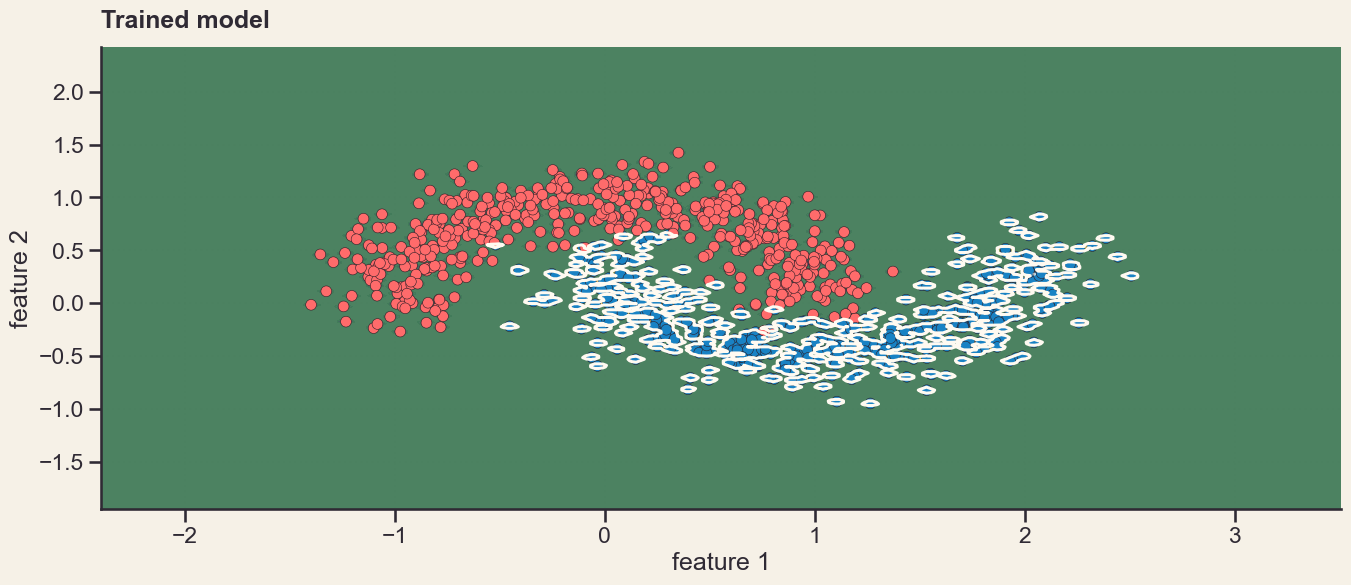

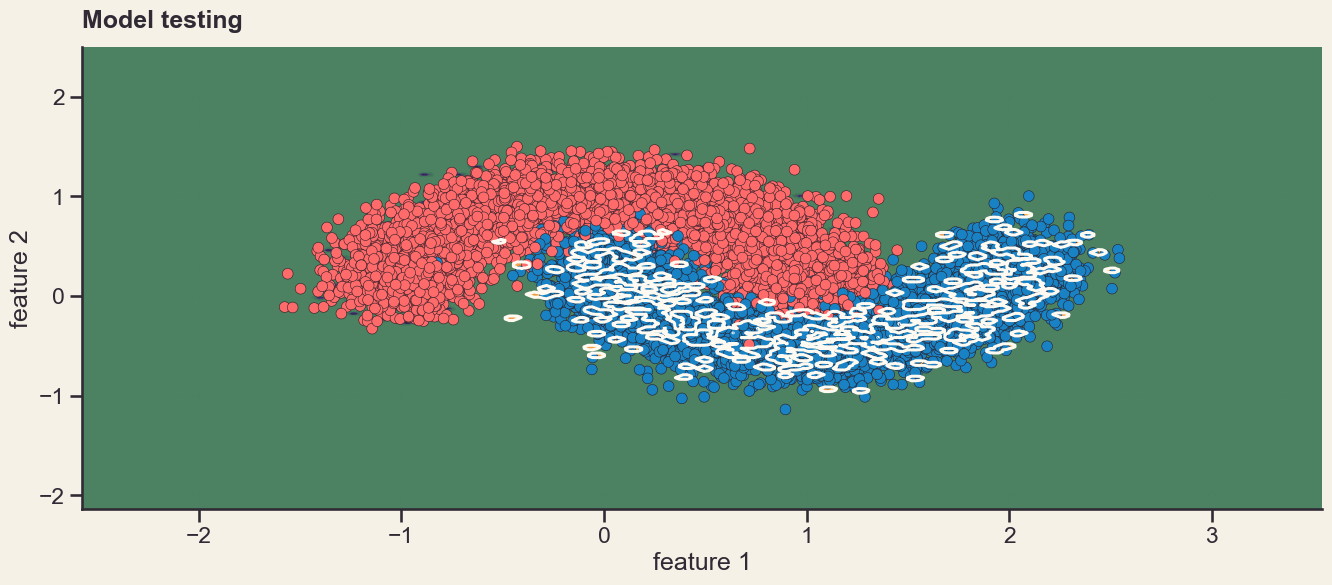

Test dataset

      metric     value
0   accuracy  0.674600
1  precision  0.979670
2     recall  0.356600
3         f1  0.522874
4    roc_auc  0.970707


In [6]:
X_moon, y_moon = make_moons(n_samples=1000, noise=0.18, random_state=42)
X_test, y_test = make_moons(n_samples=10000, noise=0.18, random_state=90)

gamma_values = [100, 1000, 5000]

for gamma in gamma_values:
    svc = Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", C=100000, gamma=gamma, probability=True))
    ])

    svc.fit(X_moon, y_moon)

    SVC_pred = svc.predict(X_test)
    SVC_prob = svc.predict_proba(X_test)[:,1]

    metric = metric_frame(y_test, SVC_pred, SVC_prob)

    fig, ax = plt.subplots(figsize=(16, 6))
    plot_surface(ax, svc, X_moon, y_moon, "Trained model")
    plt.show()

    fig, ax = plt.subplots(figsize=(16, 6))
    plot_surface(ax, svc, X_test, y_test, "Model testing")
    plt.show()

    print("Test dataset\n")
    display(metric)


Overfitting results in incorrect classification of test data.

# Add class_weight="balanced" and test what changes on imbalanced synthetic data.


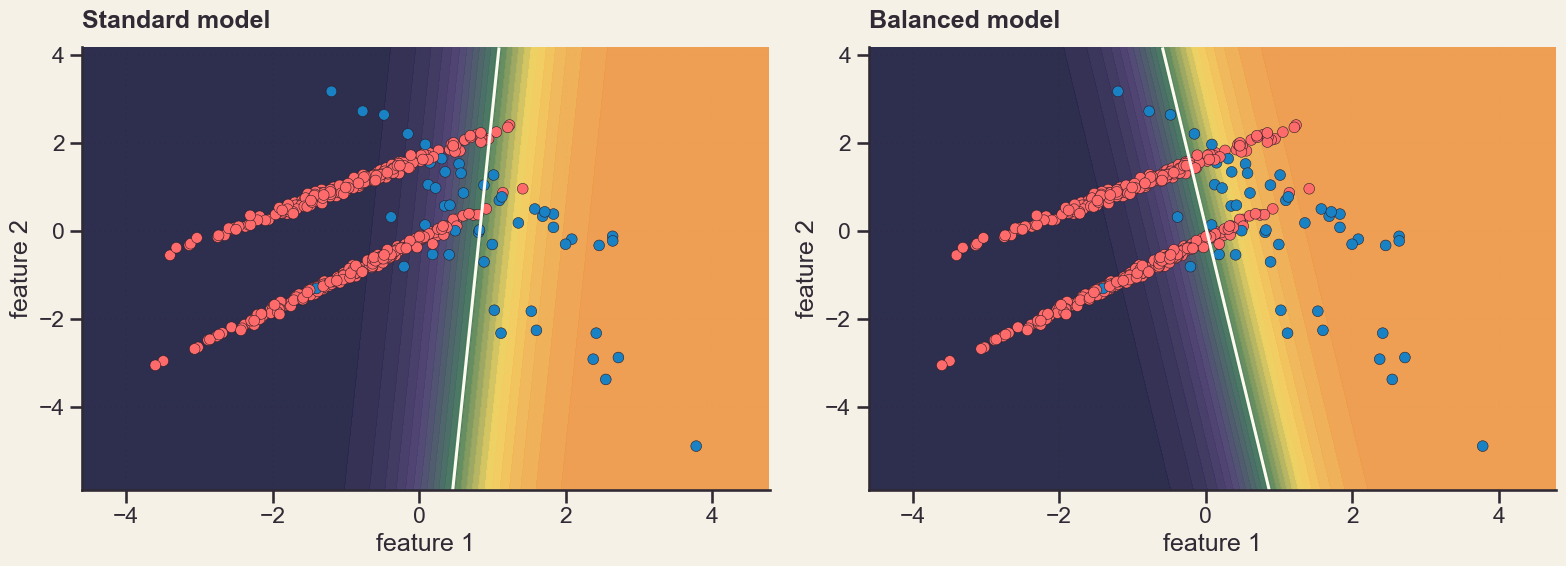


Imbalanced Metrics:
      metric     value
0   accuracy  0.952000
1  precision  1.000000
2     recall  0.400000
3         f1  0.571429
4    roc_auc  0.846087

Balanced Metrics:
      metric     value
0   accuracy  0.824000
1  precision  0.269231
2     recall  0.700000
3         f1  0.388889
4    roc_auc  0.843478


In [7]:
X_imb, y_imb = make_classification(n_samples=500, n_features=2, n_redundant=0, n_informative=2, weights=[0.9, 0.1], random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X_imb, y_imb, test_size=0.25, random_state=42)

# imbalanced model
logreg_imb = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])
logreg_imb.fit(X_train, y_train)

# balanced model
logreg_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

logreg_balanced.fit(X_train, y_train)

imb_pred = logreg_imb.predict(X_test)
imb_prob = logreg_imb.predict_proba(X_test)[:, 1]
metrics_imb = metric_frame(y_test, imb_pred, imb_prob)

balanced_pred = logreg_balanced.predict(X_test)
balanced_prob = logreg_balanced.predict_proba(X_test)[:,1]
metrics_balanced = metric_frame(y_test, balanced_pred, balanced_prob)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_surface(axes[0], logreg_imb, X_imb, y_imb, "Standard model")
plot_surface(axes[1], logreg_balanced, X_imb, y_imb, "Balanced model")

plt.tight_layout()
plt.show()

print("\nImbalanced Metrics:")
display(metrics_imb)
print("\nBalanced Metrics:")
display(metrics_balanced)


Adding class_weight="balanced" forces the model to impose a higher penalty for misclassifying the minority class. In this dataset (90% majority, 10% minority).

As a result the completeness for the minority class is significantly improved in the balanced model compared to the unbalanced model. However this comes at the expense of reduced precision and overall reliability as the model predicts more false positives for the majority class.


# Compare LinearSVC and SVC(kernel="linear") on runtime and quality.

In [8]:
import time

X, y = make_classification(n_samples=20000, n_features=10, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

lin_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearSVC(random_state=42))
])

start_time = time.time()
lin_svc.fit(X_train, y_train)
lin_svc_time = time.time() - start_time

svc_lin = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", random_state=42))
])

start_time = time.time()
svc_lin.fit(X_train, y_train)
svc_lin_time = time.time() - start_time

lin_svc_pred = lin_svc.predict(X_test)
lin_svc_prob = lin_svc.decision_function(X_test)
metrics_lin_svc = metric_frame(y_test, lin_svc_pred, lin_svc_prob)

svc_lin_pred= svc_lin.predict(X_test)
svc_lin_prob = svc_lin.decision_function(X_test)
metrics_svc_lin = metric_frame(y_test, svc_lin_pred, svc_lin_prob)

print(f"LinearSVC training time: {lin_svc_time:.4f} seconds")
print(f"SVC(kernel='linear') training time: {svc_lin_time:.4f} seconds\n")

print("--- QUALITY: LinearSVC Metrics ---")
display(metrics_lin_svc.round(3))

print("\n--- QUALITY: SVC(kernel='linear') Metrics ---")
display(metrics_svc_lin.round(3))


LinearSVC training time: 0.0209 seconds
SVC(kernel='linear') training time: 2.4194 seconds

--- QUALITY: LinearSVC Metrics ---
      metric  value
0   accuracy  0.877
1  precision  0.922
2     recall  0.826
3         f1  0.871
4    roc_auc  0.926

--- QUALITY: SVC(kernel='linear') Metrics ---
      metric  value
0   accuracy  0.882
1  precision  0.934
2     recall  0.823
3         f1  0.875
4    roc_auc  0.925


LinearSVC is significantly faster during training compared to SVC(kernel="linear").
Despite the significant difference in training time the classification quality and resulting performance are almost identical for both models.